In [2]:
import sys
print(sys.executable)


import torch
print(torch.__version__)       # 2.1.2
print(torch.cuda.is_available()) # True

/home/rashadulnafisriyad/miniconda3/envs/lweunet/bin/python
2.2.2+cu121
True


In [4]:
import numpy as np
import pandas as pd
import nibabel as nib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path
from collections import defaultdict

RAW_DIR = Path("../data/raw/training")

# ── Build inventory ───────────────────────────────────────────
records = []

for patient_dir in sorted(RAW_DIR.iterdir()):
    if not patient_dir.is_dir():
        continue

    pid = patient_dir.name

    # Read Info.cfg
    info = {}
    with open(patient_dir / "Info.cfg") as f:
        for line in f:
            if ":" in line:
                k, v = line.strip().split(":", 1)
                info[k.strip()] = v.strip()

    ed_frame = int(info["ED"])
    es_frame = int(info["ES"])
    group    = info.get("Group", "RV")
    if group == "RV":
        group = "ARV"

    # Load ED volume for metadata
    def find_nii(base):
        for ext in [".nii.gz", ".nii"]:
            p = Path(str(base) + ext)
            if p.exists():
                return p
        return None

    ed_path = find_nii(patient_dir / f"{pid}_frame{ed_frame:02d}")
    es_path = find_nii(patient_dir / f"{pid}_frame{es_frame:02d}")

    ed_img  = nib.load(str(ed_path))
    es_img  = nib.load(str(es_path))

    ed_data = ed_img.get_fdata()
    es_data = es_img.get_fdata()

    spacing = ed_img.header.get_zooms()

    # Load masks
    ed_msk_path = find_nii(
        patient_dir / f"{pid}_frame{ed_frame:02d}_gt"
    )
    ed_msk = nib.load(str(ed_msk_path)).get_fdata().astype(np.uint8)

    records.append({
        "patient_id"       : pid,
        "group"            : group,
        "ed_frame"         : ed_frame,
        "es_frame"         : es_frame,
        "height_mm"        : float(info.get("Height", 0)),
        "weight_kg"        : float(info.get("Weight", 0)),
        "n_slices"         : ed_data.shape[2],
        "image_rows"       : ed_data.shape[0],
        "image_cols"       : ed_data.shape[1],
        "spacing_x_mm"     : round(float(spacing[0]), 3),
        "spacing_y_mm"     : round(float(spacing[1]), 3),
        "spacing_z_mm"     : round(float(spacing[2]), 3),
        "ed_intensity_min" : float(ed_data.min()),
        "ed_intensity_max" : float(ed_data.max()),
        "ed_intensity_mean": round(float(ed_data.mean()), 2),
        "ed_intensity_std" : round(float(ed_data.std()), 2),
        "es_intensity_mean": round(float(es_data.mean()), 2),
        "lv_present"       : int(np.any(ed_msk == 3)),
        "rv_present"       : int(np.any(ed_msk == 1)),
        "myo_present"      : int(np.any(ed_msk == 2)),
    })

df = pd.DataFrame(records)
print(f"Inventory built: {len(df)} patients")
print(df.head())
df.to_csv("../data/splits/dataset_inventory.csv", index=False)

Inventory built: 100 patients
   patient_id group  ed_frame  es_frame  height_mm  weight_kg  n_slices  \
0  patient001   DCM         1        12      184.0       95.0        10   
1  patient002   DCM         1        12      160.0       70.0        10   
2  patient003   DCM         1        15      165.0       77.0        10   
3  patient004   DCM         1        15      159.0       46.0        10   
4  patient005   DCM         1        13      165.0       77.0        10   

   image_rows  image_cols  spacing_x_mm  spacing_y_mm  spacing_z_mm  \
0         216         256         1.562         1.562          10.0   
1         232         256         1.367         1.367          10.0   
2         256         256         1.562         1.562          10.0   
3         232         256         1.367         1.367          10.0   
4         256         216         1.406         1.406          10.0   

   ed_intensity_min  ed_intensity_max  ed_intensity_mean  ed_intensity_std  \
0             

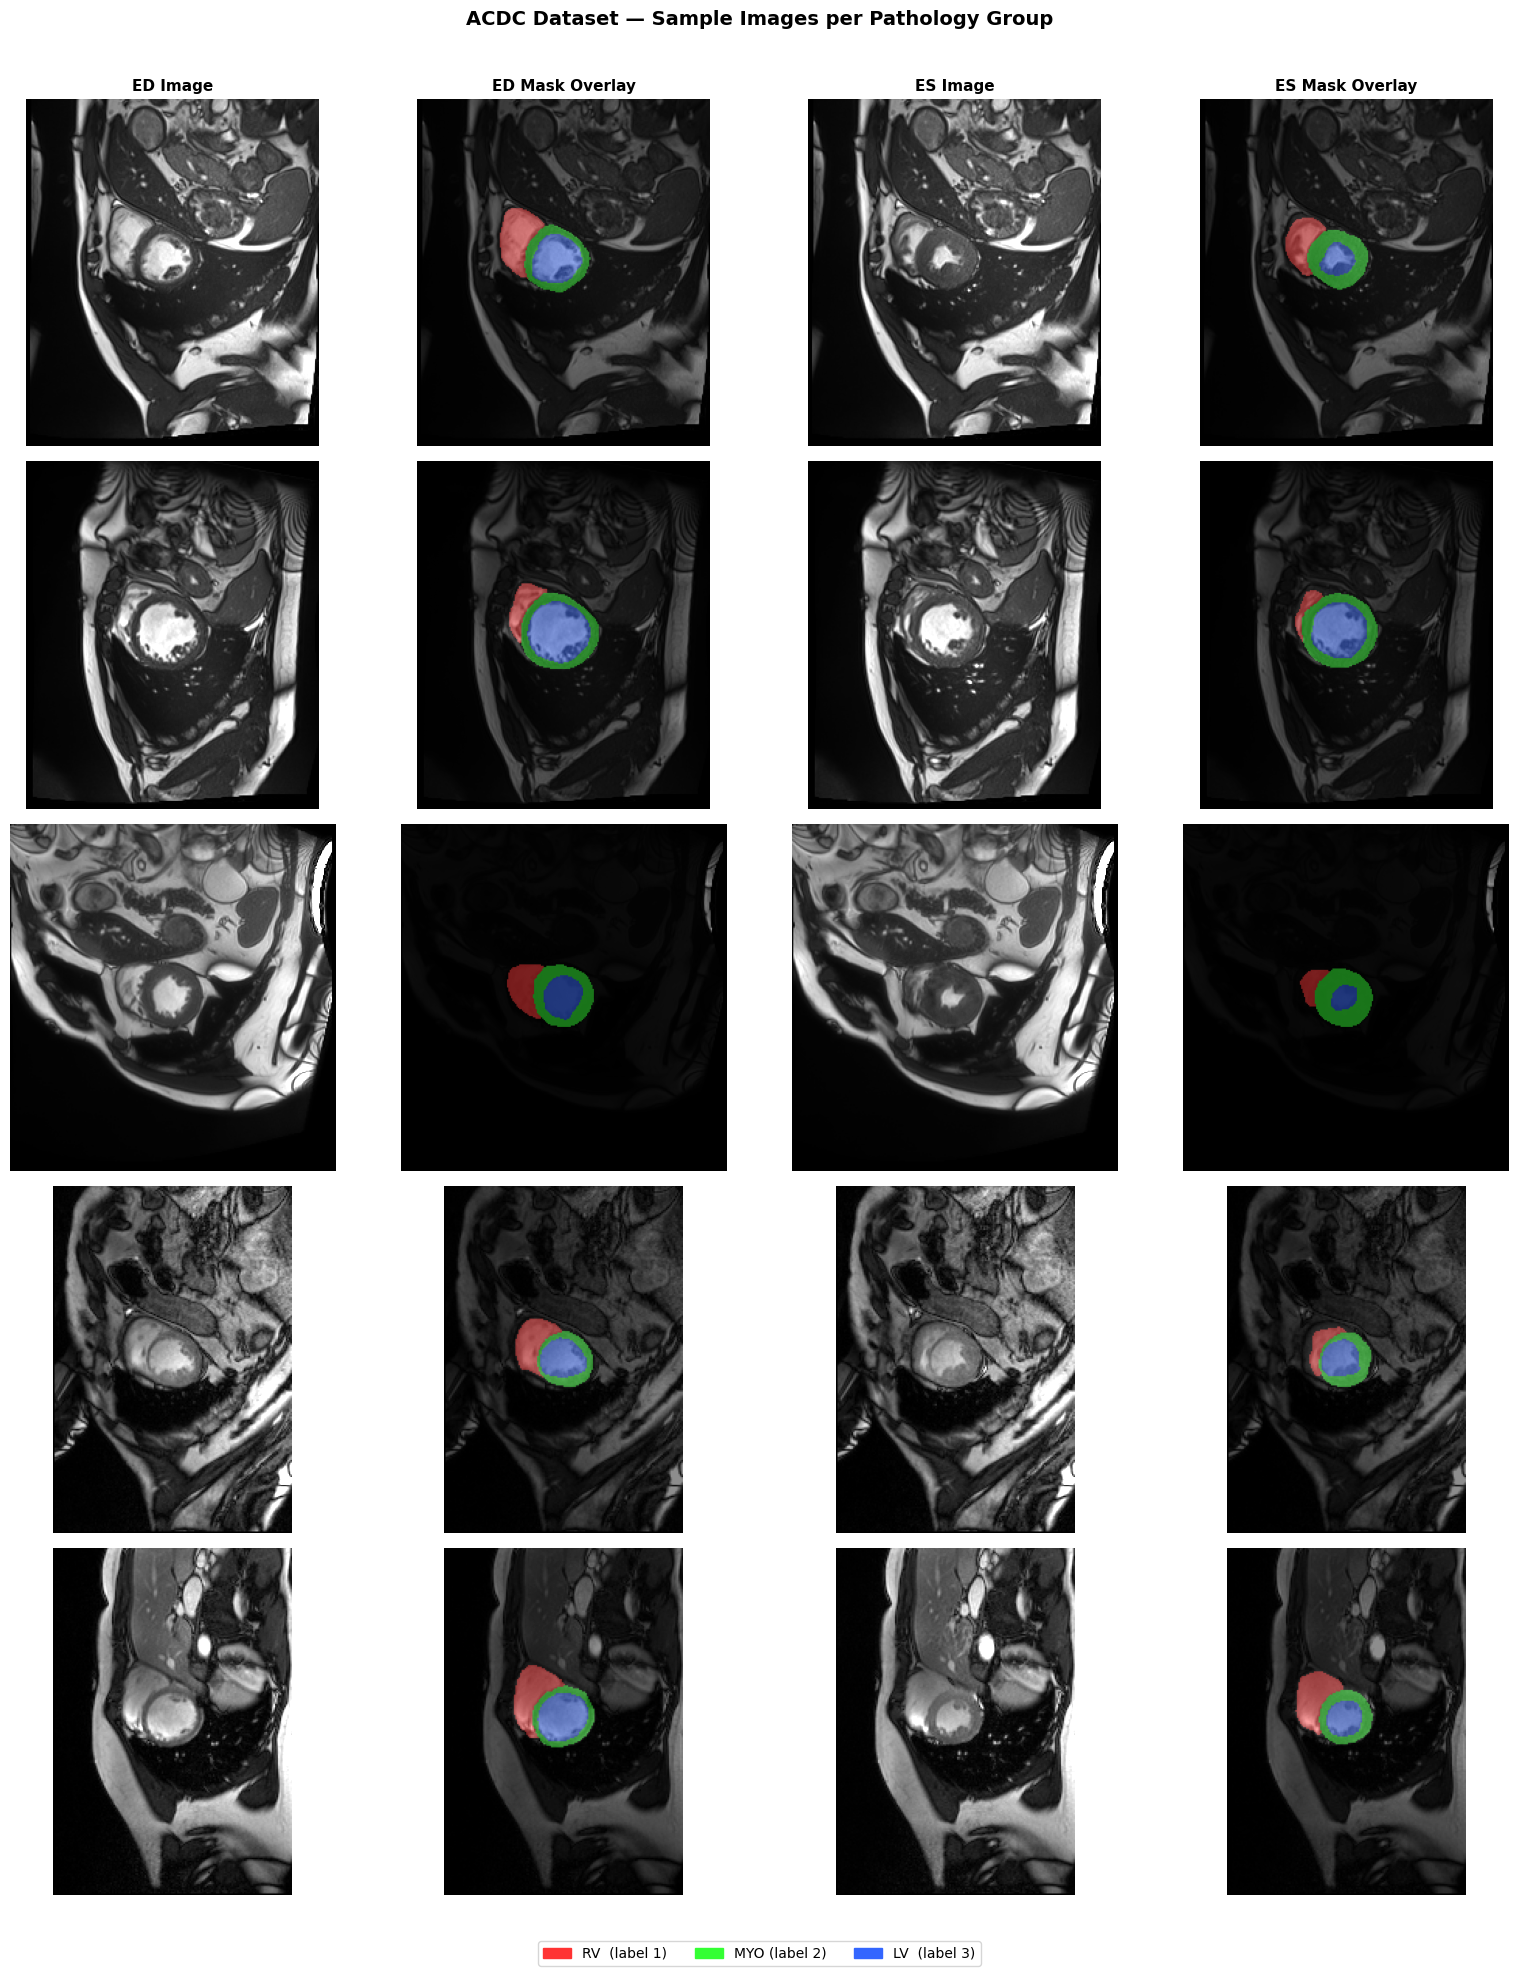

Saved: data/splits/sample_images_per_group.png


In [8]:
# Cell 2 — Visualise one patient per group

GROUP_COLORS = {
    0: [0.0, 0.0, 0.0],   # Background — black
    1: [1.0, 0.2, 0.2],   # RV         — red
    2: [0.2, 1.0, 0.2],   # MYO        — green
    3: [0.2, 0.4, 1.0],   # LV         — blue
}

def colorise_mask(mask_2d):
    """Convert integer mask to RGB colour image."""
    rgb = np.zeros((*mask_2d.shape, 3))
    for label, color in GROUP_COLORS.items():
        rgb[mask_2d == label] = color
    return rgb

def load_middle_slice(patient_dir, frame_id, is_mask=False):
    """Load the middle axial slice from a volume."""
    pid  = patient_dir.name
    suffix = "_gt" if is_mask else ""
    base = patient_dir / f"{pid}_frame{frame_id:02d}{suffix}"
    for ext in [".nii.gz", ".nii"]:
        p = Path(str(base) + ext)
        if p.exists():
            vol = nib.load(str(p)).get_fdata()
            mid = vol.shape[2] // 2
            return vol[:, :, mid]
    return None

# One patient per group
groups       = ["NOR", "DCM", "HCM", "MINF", "ARV"]
group_map    = {"ARV": "RV", "RV": "ARV"}  # handle both labels
sample_pids  = {}

for _, row in df.iterrows():
    g = row["group"]
    if g not in sample_pids and g in groups:
        sample_pids[g] = row

fig, axes = plt.subplots(
    len(groups), 4,
    figsize=(16, 4 * len(groups))
)
fig.suptitle(
    "ACDC Dataset — Sample Images per Pathology Group",
    fontsize=14, fontweight="bold"
)

col_titles = ["ED Image", "ED Mask Overlay", "ES Image", "ES Mask Overlay"]
for ax, title in zip(axes[0], col_titles):
    ax.set_title(title, fontsize=11, fontweight="bold")

for row_idx, group in enumerate(groups):
    if group not in sample_pids:
        continue

    row      = sample_pids[group]
    pid      = row["patient_id"]
    pdir     = RAW_DIR / pid
    ed_frame = int(row["ed_frame"])
    es_frame = int(row["es_frame"])

    for col_offset, frame_id in enumerate([ed_frame, es_frame]):
        img_slice = load_middle_slice(pdir, frame_id, is_mask=False)
        msk_slice = load_middle_slice(pdir, frame_id, is_mask=True)

        ax_img  = axes[row_idx][col_offset * 2]
        ax_over = axes[row_idx][col_offset * 2 + 1]

        # Raw image
        ax_img.imshow(
            img_slice.T,
            cmap="gray",
            origin="lower",
            vmin=np.percentile(img_slice, 1),
            vmax=np.percentile(img_slice, 99)
        )
        ax_img.set_ylabel(
            f"{group}\n{pid}",
            fontsize=9, rotation=0, labelpad=50
        )
        ax_img.axis("off")

        # Overlay
        ax_over.imshow(img_slice.T, cmap="gray", origin="lower")
        if msk_slice is not None:
            colored = colorise_mask(msk_slice.astype(np.uint8).T)
            ax_over.imshow(colored, alpha=0.45, origin="lower")
        ax_over.axis("off")

# Legend
patches = [
    mpatches.Patch(color=[1.0, 0.2, 0.2], label="RV  (label 1)"),
    mpatches.Patch(color=[0.2, 1.0, 0.2], label="MYO (label 2)"),
    mpatches.Patch(color=[0.2, 0.4, 1.0], label="LV  (label 3)"),
]
fig.legend(
    handles=patches, loc="lower center",
    ncol=3, fontsize=10, frameon=True
)

plt.tight_layout(rect=[0, 0.03, 1, 0.97])
plt.savefig("../data/splits/sample_images_per_group.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("Saved: data/splits/sample_images_per_group.png")